# ПРОЕКТ: Анализ розничных продаж (Online Retail II)


## Краткое описание датасета Online Retail II


`Online Retail II` — это набор данных о транзакциях интернет-магазина, который специализируется на уникальных подарках и сувенирах. Он представляет собой классический пример данных для **RFM-анализа (Recency, Frequency, Monetary)** и сегментации клиентов.

**Период сбора данных:** 1 декабря 2009 года по 9 декабря 2011 года

**Особенности данных:**
- Содержит информацию об отменах и возвратах (записи с `Quantity` < 0 или `InvoiceNo`, начинающиеся на 'C')
- Есть пропуски в поле `CustomerID`




## Источник и лицензия

| Параметр | Значение |
|----------|----------|
| **Правообладатель** | Dr. Daqing Chen, Лондонский университет Саут-Бэнк |
| **Источник** | UCI Machine Learning Repository |
| **Прямая ссылка** | [Online Retail II Data Set](https://archive.ics.uci.edu/dataset/502/online+retail+ii) |
| **Лицензия** | Creative Commons Attribution 4.0 International (CC BY 4.0) |



## Описание полей (атрибуты)

| Поле | Тип | Описание |
|------|-----|-----------|
| `InvoiceNo` | Nominal | Номер счета/чека (6 цифр). Если начинается с 'C' — отмена заказа |
| `StockCode` | Nominal | Уникальный код товара (5 цифр) |
| `Description` | Nominal | Название товара |
| `Quantity` | Numeric | Количество единиц товара в транзакции (может быть отрицательным) |
| `InvoiceDate` | Numeric | Дата и время совершения операции |
| `UnitPrice` | Numeric | Цена за единицу товара в фунтах стерлингов (£) |
| `CustomerID` | Nominal | Уникальный идентификатор покупателя (5 цифр). **Есть пропуски** |
| `Country` | Nominal | Название страны проживания клиента |











In [1]:
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 1. ИМПОРТ И НАСТРОЙКИ
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 2. ЗАГРУЗКА ДАННЫХ
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 3. ПРОФИЛИРОВАНИЕ ДАННЫХ
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 4. ОЧИСТКА ДАННЫХ
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 5. СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

In [2]:
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 1. ИМПОРТ БИБЛИОТЕК
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# ЗАГРУЗКА ДАННЫХ (ОБА ЛИСТА)
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

import pandas as pd

# Загружаем оба листа
df_2009 = pd.read_excel('../online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2010 = pd.read_excel('../online_retail_II.xlsx', sheet_name='Year 2010-2011')

print("="*50)
print("ЗАГРУЗКА ДАННЫХ")
print("="*50)
print(f"Лист 2009-2010: {df_2009.shape[0]:,} строк, {df_2009.shape[1]} колонок")
print(f"Лист 2010-2011: {df_2010.shape[0]:,} строк, {df_2010.shape[1]} колонок")

# Объединяем в один датафрейм
df = pd.concat([df_2009, df_2010], ignore_index=True)

print(f"\nОбъединённые данные: {df.shape[0]:,} строк, {df.shape[1]} колонок")
print(f"\nДиапазон дат:")
print(f"   Min: {df['InvoiceDate'].min()}")
print(f"   Max: {df['InvoiceDate'].max()}")

ЗАГРУЗКА ДАННЫХ
Лист 2009-2010: 525,461 строк, 8 колонок
Лист 2010-2011: 541,910 строк, 8 колонок

Объединённые данные: 1,067,371 строк, 8 колонок

Диапазон дат:
   Min: 2009-12-01 07:45:00
   Max: 2011-12-09 12:50:00


In [16]:
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 3. ПРОФИЛИРОВАНИЕ ДАННЫХ
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

print("\n" + "="*50)
print("ПРОФИЛИРОВАНИЕ ДАННЫХ")
print("="*50)

print("\nТИПЫ ДАННЫХ:")
print(df.dtypes)

print("\nСТАТИСТИКА ПО ЧИСЛОВЫМ КОЛОНКАМ:")
print(df[['Quantity', 'Price']].describe())

print("\nПРОВЕРКА ПРОПУСКОВ:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing, '%': missing_pct})
print(missing_df[missing_df['Пропуски'] > 0])

print("\nТОП-5 СТРАН ПО КОЛИЧЕСТВУ ЗАКАЗОВ:")
print(df['Country'].value_counts().head(5))

print("\nАНОМАЛИИ:")
print(f"Отрицательные Quantity: {(df['Quantity'] < 0).sum():,}")
print(f"Отрицательные Price: {(df['Price'] < 0).sum():,}")
print(f"Дубликаты строк: {df.duplicated().sum():,}")


ПРОФИЛИРОВАНИЕ ДАННЫХ

ТИПЫ ДАННЫХ:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

СТАТИСТИКА ПО ЧИСЛОВЫМ КОЛОНКАМ:
           Quantity         Price
count  1.067371e+06  1.067371e+06
mean   9.938898e+00  4.649388e+00
std    1.727058e+02  1.235531e+02
min   -8.099500e+04 -5.359436e+04
25%    1.000000e+00  1.250000e+00
50%    3.000000e+00  2.100000e+00
75%    1.000000e+01  4.150000e+00
max    8.099500e+04  3.897000e+04

ПРОВЕРКА ПРОПУСКОВ:
             Пропуски          %
Description      4382   0.410541
Customer ID    243007  22.766873

ТОП-5 СТРАН ПО КОЛИЧЕСТВУ ЗАКАЗОВ:
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Name: count, dtype: int64

АНОМАЛИИ:
Отрицательные Quantity: 22,950
Отрицательны

In [17]:
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 4. ОЧИСТКА ДАННЫХ
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

print("\n" + "="*50)
print("ОЧИСТКА ДАННЫХ")
print("="*50)

# 4.1 Копируем исходные данные
df_clean = df.copy()

# 4.2 Удаляем возвраты (Quantity < 0)
df_clean = df_clean[df_clean['Quantity'] > 0]
print("Удалены записи с Quantity < 0 (возвраты)")

# 4.3 Удаляем аномальные цены (Price < 0)
df_clean = df_clean[df_clean['Price'] > 0]
print("Удалены записи с Price < 0 (аномалии)")

# 4.4 Удаляем строки без Customer ID
df_clean = df_clean.dropna(subset=['Customer ID'])
print("Удалены записи без Customer ID")

# 4.5 Удаляем дубликаты
df_clean = df_clean.drop_duplicates()
print("Удалены дубликаты строк")




ОЧИСТКА ДАННЫХ
Удалены записи с Quantity < 0 (возвраты)
Удалены записи с Price < 0 (аномалии)
Удалены записи без Customer ID
Удалены дубликаты строк


In [18]:
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 5. ПРОВЕРКА КАЧЕСТВА ОЧИСТКИ
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

print("\n" + "="*50)
print("ПРОВЕРКА КАЧЕСТВА ОЧИСТКИ")
print("="*50)

print(f"Исходные данные:   {len(df):,} строк")
print(f"После очистки:     {len(df_clean):,} строк")
print(f"Удалено:           {len(df) - len(df_clean):,} строк ({((len(df)-len(df_clean))/len(df)*100):.1f}%)")

print(f"\nДетали очистки:")
print(f"   • Клиентов осталось:   {df_clean['Customer ID'].nunique():,}")
print(f"   • Транзакций осталось: {df_clean['Invoice'].nunique():,}")
print(f"   • Товаров осталось:    {df_clean['StockCode'].nunique():,}")

# Проверка отсутствия аномалий
print(f"\nФинальная проверка:")
print(f"   Quantity < 0: {(df_clean['Quantity'] < 0).sum()}")
print(f"   Price < 0: {(df_clean['Price'] < 0).sum()}")
print(f"   Customer ID пропуски: {df_clean['Customer ID'].isnull().sum()}")
print(f"   Дубликаты: {df_clean.duplicated().sum()}")


ПРОВЕРКА КАЧЕСТВА ОЧИСТКИ
Исходные данные:   1,067,371 строк
После очистки:     779,425 строк
Удалено:           287,946 строк (27.0%)

Детали очистки:
   • Клиентов осталось:   5,878
   • Транзакций осталось: 36,969
   • Товаров осталось:    4,631

Финальная проверка:
   Quantity < 0: 0
   Price < 0: 0
   Customer ID пропуски: 0
   Дубликаты: 0


In [ ]:
# 4.6 Создаём колонку TotalPrice
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
print("Создана колонка TotalPrice = Quantity × Price")


✅ Создана колонка TotalPrice = Quantity × Price


# ОБЩАЯ АНАЛИТИКА (KPI)

In [7]:
print("="*60)
print("📊 ОБЩАЯ АНАЛИТИКА - КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ")
print("="*60)

# KPI метрики
total_revenue = df_clean['TotalPrice'].sum()
total_customers = df_clean['Customer ID'].nunique()
total_orders = df_clean['Invoice'].nunique()
avg_order_value = total_revenue / total_orders
avg_items_per_order = df_clean.groupby('Invoice')['Quantity'].sum().mean()

# Отток (клиенты с 1 покупкой)
one_time_customers = df_clean.groupby('Customer ID')['Invoice'].nunique()
one_time_customers = (one_time_customers == 1).sum()
churn_rate = (one_time_customers / total_customers) * 100

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                       ОСНОВНЫЕ KPI                               │
├─────────────────────────────────────────────────────────────────┤
│ 💰 Общая выручка:          {total_revenue:>15,.2f} £              │
│ 👥 Всего клиентов:         {total_customers:>15,}                 │
│ 🧾 Всего заказов:           {total_orders:>15,}                   │
│ 💳 Средний чек:            {avg_order_value:>15,.2f} £              │
│ 📦 Среднее товаров в чеке: {avg_items_per_order:>15.1f}           │
│ ⚠️ Отток (1 покупка):      {churn_rate:>14.1f}%                   │
└─────────────────────────────────────────────────────────────────┘
""")

📊 ОБЩАЯ АНАЛИТИКА - КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ

┌─────────────────────────────────────────────────────────────────┐
│                       ОСНОВНЫЕ KPI                               │
├─────────────────────────────────────────────────────────────────┤
│ 💰 Общая выручка:            17,374,804.27 £              │
│ 👥 Всего клиентов:                   5,878                 │
│ 🧾 Всего заказов:                    36,969                   │
│ 💳 Средний чек:                     469.98 £              │
│ 📦 Среднее товаров в чеке:           284.4           │
│ ⚠️ Отток (1 покупка):                27.6%                   │
└─────────────────────────────────────────────────────────────────┘



# 2. ДИНАМИКА ПОКАЗАТЕЛЕЙ (MoM, YoY, YTD, скользящие средние)


📈 ДИНАМИКА ПО МЕСЯЦАМ:
YearMonth  TotalPrice YearMonth_str  MoM_Change         MA_3          MA_6
  2011-03  594081.760       2011-03   33.176831 5.360893e+05 729710.458667
  2011-04  468374.331       2011-04  -21.159954 5.028470e+05 635587.512167
  2011-05  677355.150       2011-05   44.618333 5.799371e+05 554070.033500
  2011-06  660046.050       2011-06   -2.555395 6.019252e+05 569007.253500
  2011-07  598962.901       2011-07   -9.254377 6.454547e+05 574150.852000
  2011-08  644051.040       2011-08    7.527701 6.343533e+05 607145.205333
  2011-09  950690.202       2011-09   47.611003 7.312347e+05 666579.945667
  2011-10 1035642.450       2011-10    8.935850 8.767946e+05 761124.632167
  2011-11 1156205.610       2011-11   11.641388 1.047513e+06 840933.042167
  2011-12  517208.440       2011-12  -55.266742 9.030188e+05 817126.773833


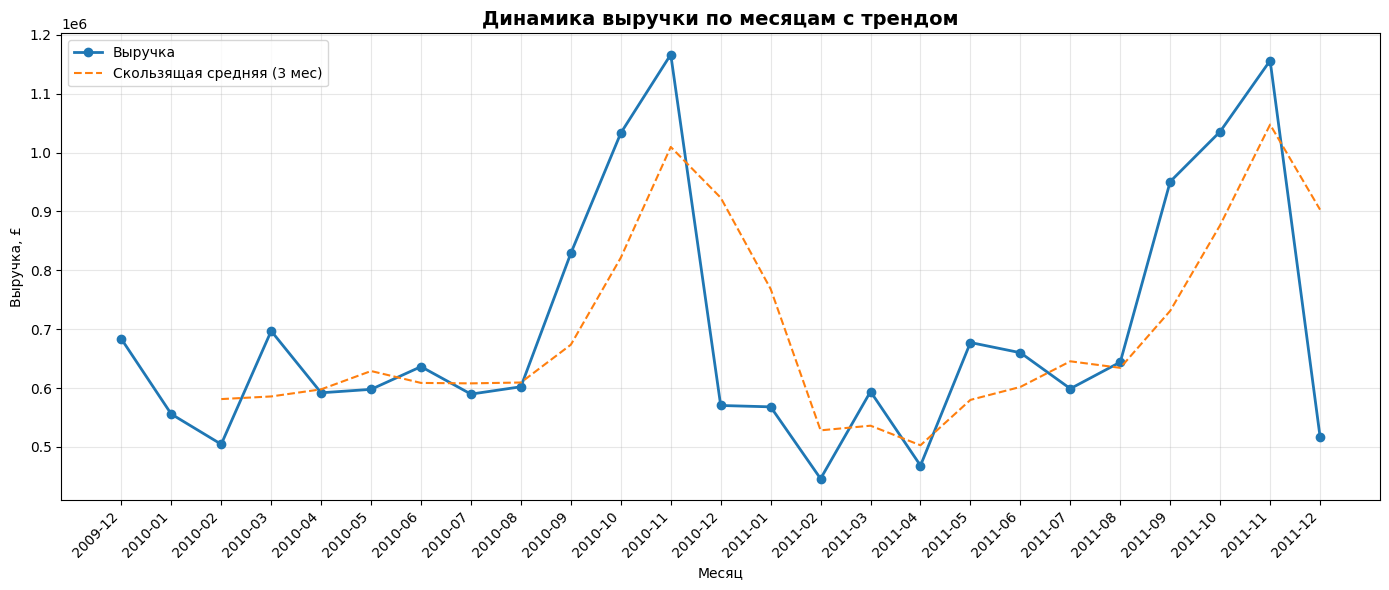

In [8]:
# Добавляем временные колонки
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Ежемесячная выручка
monthly_revenue = df_clean.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_revenue['YearMonth_str'] = monthly_revenue['YearMonth'].astype(str)

# MoM (Month over Month)
monthly_revenue['MoM_Change'] = monthly_revenue['TotalPrice'].pct_change() * 100

# Скользящие средние
monthly_revenue['MA_3'] = monthly_revenue['TotalPrice'].rolling(window=3).mean()
monthly_revenue['MA_6'] = monthly_revenue['TotalPrice'].rolling(window=6).mean()

print("\n📈 ДИНАМИКА ПО МЕСЯЦАМ:")
print(monthly_revenue.tail(10).to_string(index=False))

# График динамики
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['YearMonth_str'], monthly_revenue['TotalPrice'], 
         marker='o', linewidth=2, label='Выручка')
plt.plot(monthly_revenue['YearMonth_str'], monthly_revenue['MA_3'], 
         '--', linewidth=1.5, label='Скользящая средняя (3 мес)')
plt.title('Динамика выручки по месяцам с трендом', fontsize=14, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Выручка, £')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# 3. RFM-СЕГМЕНТАЦИЯ КЛИЕНТОВ


👥 RFM-СЕГМЕНТАЦИЯ КЛИЕНТОВ:
   Champions (лучшие): 2,059 клиентов (35.0%)
   Lost (потерянные): 2,045 клиентов (34.8%)
   At Risk (под риском): 880 клиентов (15.0%)
   Loyal (лояльные): 558 клиентов (9.5%)
   New (новые): 336 клиентов (5.7%)


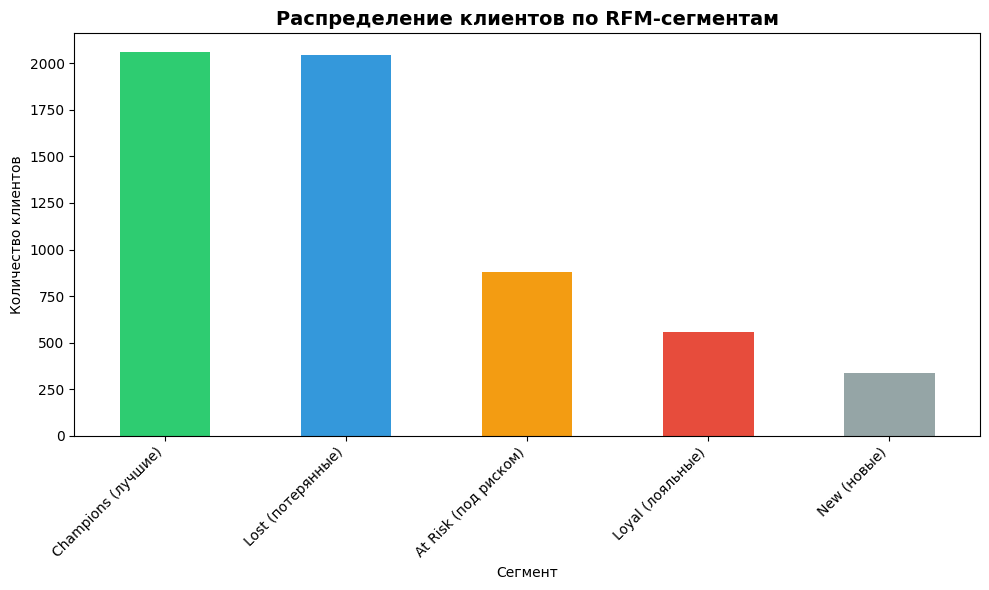

In [9]:
# Расчёт RFM
analysis_date = df_clean['InvoiceDate'].max()

rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Скоринг
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=['4', '3', '2', '1'])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=['1', '2', '3', '4'])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Сегменты
def get_segment(row):
    if row['R_Score'] >= '3' and row['F_Score'] >= '3':
        return 'Champions (лучшие)'
    elif row['R_Score'] >= '3' and row['F_Score'] >= '2':
        return 'Loyal (лояльные)'
    elif row['R_Score'] <= '2' and row['F_Score'] >= '3':
        return 'At Risk (под риском)'
    elif row['R_Score'] >= '3' and row['F_Score'] <= '2':
        return 'New (новые)'
    else:
        return 'Lost (потерянные)'

rfm['Segment'] = rfm.apply(get_segment, axis=1)

print("\n👥 RFM-СЕГМЕНТАЦИЯ КЛИЕНТОВ:")
segment_counts = rfm['Segment'].value_counts()
for seg, cnt in segment_counts.items():
    pct = (cnt / len(rfm)) * 100
    print(f"   {seg}: {cnt:,} клиентов ({pct:.1f}%)")

# Визуализация сегментов
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
segment_counts.plot(kind='bar', color=colors)
plt.title('Распределение клиентов по RFM-сегментам', fontsize=14, fontweight='bold')
plt.xlabel('Сегмент')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 4. КОГОРТНЫЙ АНАЛИЗ (матрица удержания)


📊 МАТРИЦА УДЕРЖАНИЯ КЛИЕНТОВ (%):
CohortIndex     0     1     2     3     4     5     6     7     8     9   ...  \
CohortMonth                                                               ...   
2009-12      100.0  35.3  33.4  42.5  38.0  35.9  37.7  34.2  33.6  36.2  ...   
2010-01      100.0  20.6  31.1  30.5  26.4  30.0  25.8  23.0  27.9  31.9  ...   
2010-02      100.0  23.8  22.5  29.1  24.6  20.1  19.3  28.6  25.4  27.5  ...   
2010-03      100.0  19.0  23.0  24.2  23.3  20.3  24.6  30.2  27.5  10.8  ...   
2010-04      100.0  19.4  19.4  16.3  18.4  22.4  27.6  26.2  10.5  10.9  ...   
2010-05      100.0  15.7  16.9  17.3  17.7  25.6  21.3  12.6   5.9   8.3  ...   
2010-06      100.0  17.4  18.9  20.4  23.0  28.5  12.6   8.9   8.1  11.9  ...   
2010-07      100.0  15.6  18.3  29.6  29.0  14.0  11.3  14.5  14.5  11.3  ...   
2010-08      100.0  20.4  29.6  32.1  17.3  11.7   9.9  12.3  13.6  13.0  ...   
2010-09      100.0  22.6  23.5  12.3   9.1  10.3  13.6   9.9  12.8  13.2  

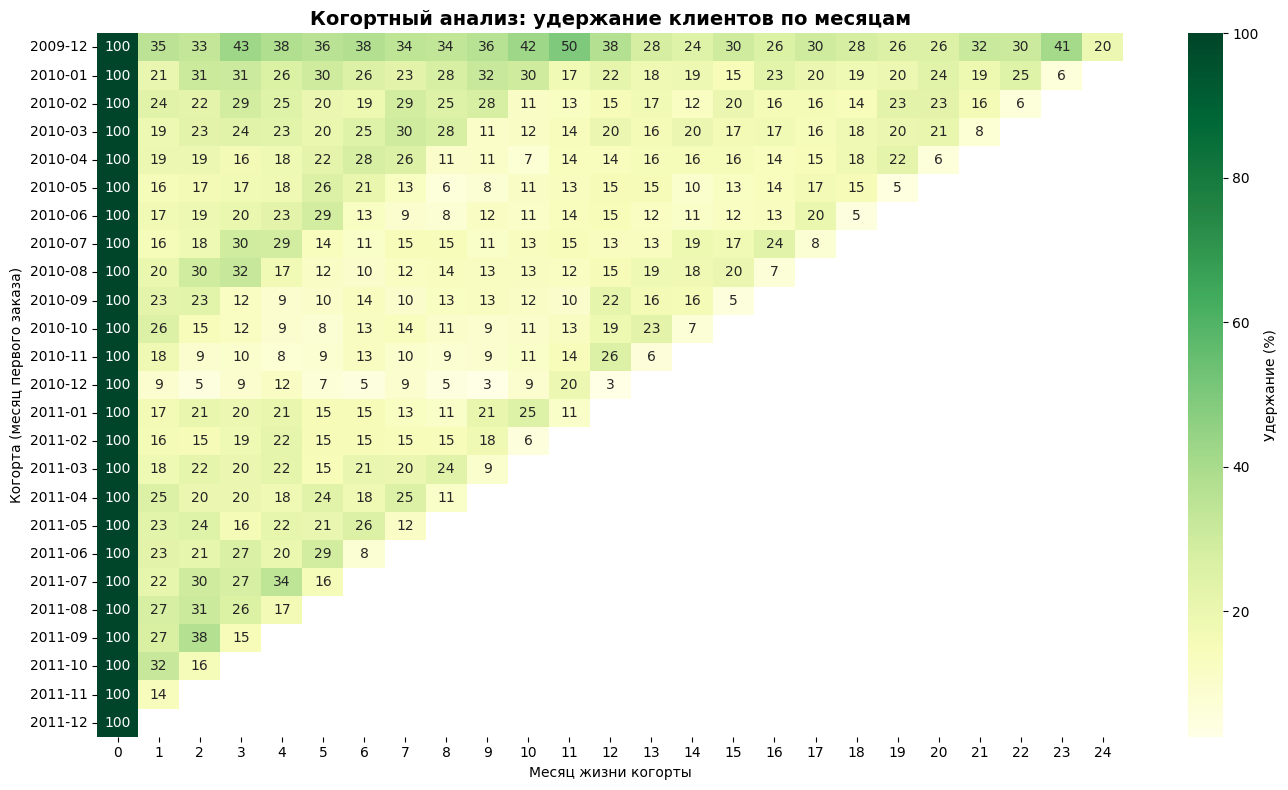

In [10]:
# Когорты по месяцу первого заказа
df_cohort = df_clean.copy()
df_cohort['CohortMonth'] = df_cohort.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
df_cohort['InvoiceMonth'] = df_cohort['InvoiceDate'].dt.to_period('M')
df_cohort['CohortIndex'] = (df_cohort['InvoiceMonth'] - df_cohort['CohortMonth']).apply(lambda x: x.n)

# Матрица удержания
retention = df_cohort.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
retention_pivot = retention.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')
retention_pct = retention_pivot.divide(retention_pivot[0], axis=0) * 100

print("\n📊 МАТРИЦА УДЕРЖАНИЯ КЛИЕНТОВ (%):")
print(retention_pct.head(10).round(1))

# Тепловая карта удержания
plt.figure(figsize=(14, 8))
sns.heatmap(retention_pct, annot=True, fmt='.0f', cmap='YlGn', 
            cbar_kws={'label': 'Удержание (%)'})
plt.title('Когортный анализ: удержание клиентов по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц жизни когорты')
plt.ylabel('Когорта (месяц первого заказа)')
plt.tight_layout()
plt.show()

# 5. ТОВАРНАЯ АНАЛИТИКА (Парето / ABC-анализ)


🏷️ ABC-АНАЛИЗ ТОВАРОВ:
   C (5%): 2784 товаров
   B (15%): 1362 товаров
   A (80%): 1137 товаров


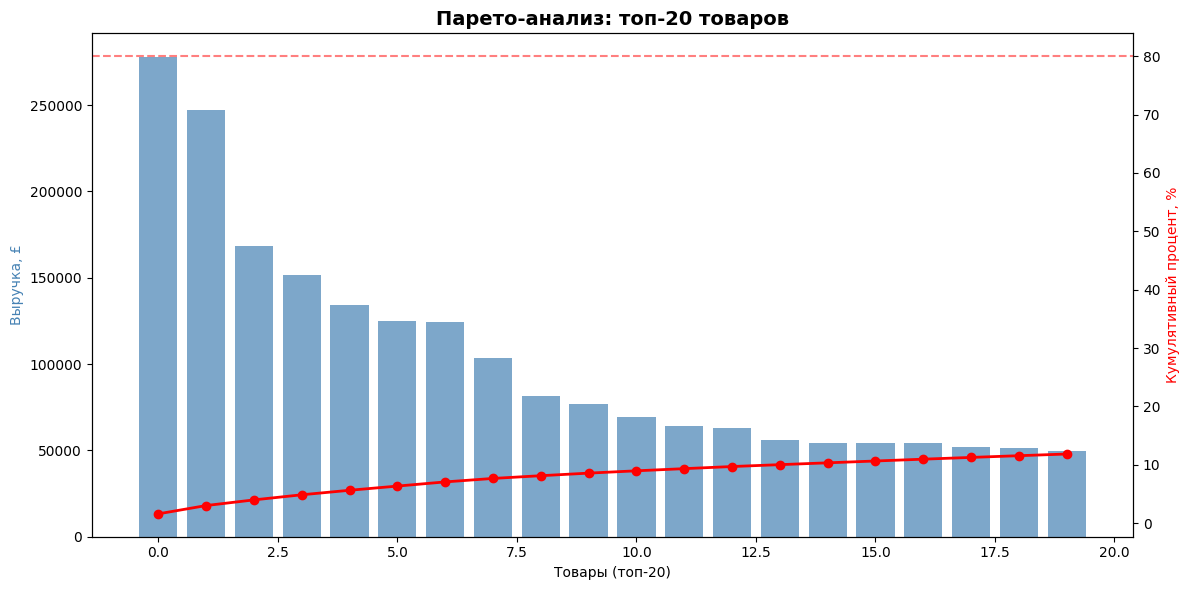

In [11]:
# ABC-анализ товаров
product_revenue = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
product_revenue['CumulativeRevenue'] = product_revenue['TotalPrice'].cumsum()
product_revenue['CumulativePct'] = (product_revenue['CumulativeRevenue'] / total_revenue) * 100

def abc_class(pct):
    if pct <= 80:
        return 'A (80%)'
    elif pct <= 95:
        return 'B (15%)'
    else:
        return 'C (5%)'

product_revenue['ABC_Class'] = product_revenue['CumulativePct'].apply(abc_class)

print("\n🏷️ ABC-АНАЛИЗ ТОВАРОВ:")
abc_counts = product_revenue['ABC_Class'].value_counts()
for abc, cnt in abc_counts.items():
    print(f"   {abc}: {cnt} товаров")

# График Парето
fig, ax1 = plt.subplots(figsize=(12, 6))

# Столбцы - выручка по товарам
top_20 = product_revenue.head(20)
ax1.bar(range(len(top_20)), top_20['TotalPrice'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Товары (топ-20)')
ax1.set_ylabel('Выручка, £', color='steelblue')

# Линия - кумулятивный процент
ax2 = ax1.twinx()
ax2.plot(range(len(top_20)), top_20['CumulativePct'].head(20), 
         color='red', marker='o', linewidth=2)
ax2.set_ylabel('Кумулятивный процент, %', color='red')
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.5)

plt.title('Парето-анализ: топ-20 товаров', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



# 6. ГЕОАНАЛИТИКА (продажи по странам)


🌍 ГЕОГРАФИЧЕСКАЯ АНАЛИТИКА:
       Country      Revenue  Customers  Orders  Revenue_Pct
United Kingdom 14389234.917       5350   33541    82.816673
          EIRE   616570.540          5     567     3.548647
   Netherlands   554038.090         22     228     3.188744
       Germany   425019.711        107     789     2.446184
        France   348768.960         95     614     2.007326
     Australia   169283.460         15      95     0.974304
         Spain   108332.490         41     154     0.623503
   Switzerland   100061.940         22      90     0.575903
        Sweden    91515.820         19     104     0.526716
       Denmark    68580.690         12      43     0.394713


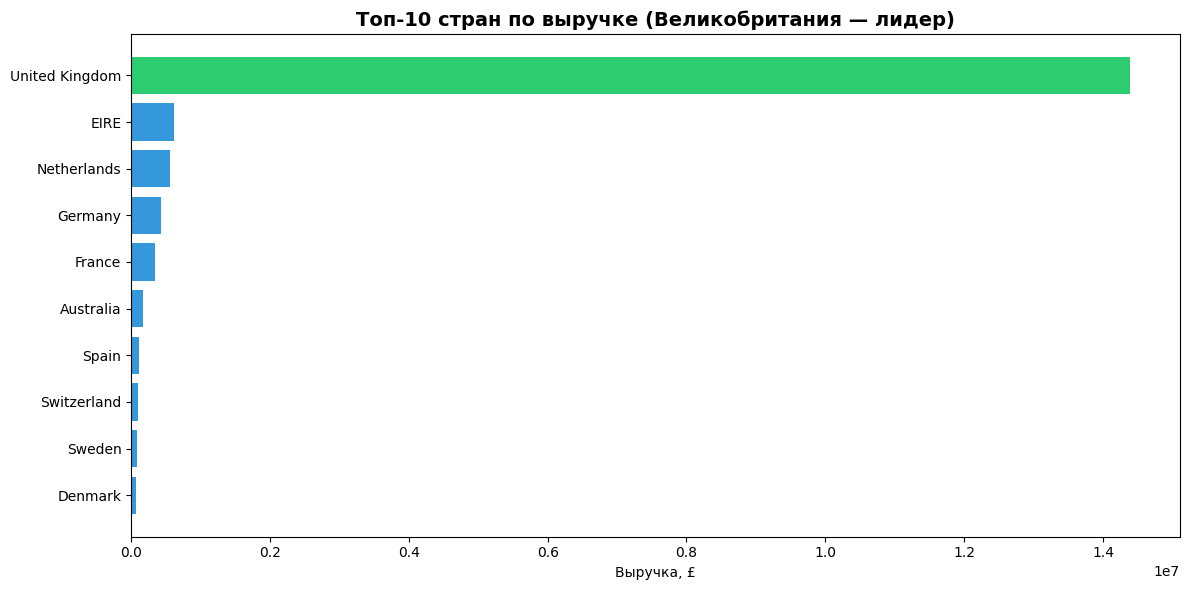

In [12]:
country_stats = df_clean.groupby('Country').agg({
    'TotalPrice': 'sum',
    'Customer ID': 'nunique',
    'Invoice': 'nunique'
}).sort_values('TotalPrice', ascending=False).reset_index()

country_stats.columns = ['Country', 'Revenue', 'Customers', 'Orders']
country_stats['Revenue_Pct'] = (country_stats['Revenue'] / total_revenue) * 100

print("\n🌍 ГЕОГРАФИЧЕСКАЯ АНАЛИТИКА:")
print(country_stats.head(10).to_string(index=False))

# Топ-10 стран по выручке
plt.figure(figsize=(12, 6))
top_countries = country_stats.head(10)
colors = ['#2ecc71' if c == 'United Kingdom' else '#3498db' for c in top_countries['Country']]
plt.barh(range(len(top_countries)), top_countries['Revenue'], color=colors)
plt.yticks(range(len(top_countries)), top_countries['Country'])
plt.xlabel('Выручка, £')
plt.title('Топ-10 стран по выручке (Великобритания — лидер)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 7. КЛИЕНТСКАЯ АНАЛИТИКА (сегменты, LTV, распределение)


💰 СРЕДНИЙ LTV ПО СЕГМЕНТАМ:
   Champions (лучшие): 23.23 £
   Loyal (лояльные): 20.90 £
   At Risk (под риском): 19.91 £
   Lost (потерянные): 18.97 £
   New (новые): 16.98 £


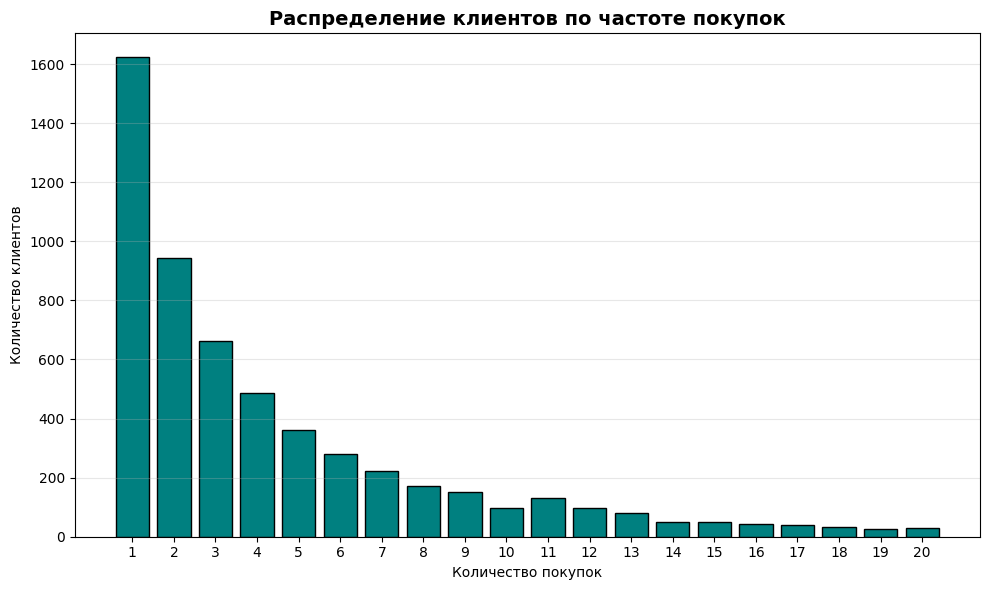

In [13]:
# LTV по сегментам
customer_segments = df_clean.merge(rfm[['CustomerID', 'Segment']], left_on='Customer ID', right_on='CustomerID')
segment_ltv = customer_segments.groupby('Segment')['TotalPrice'].mean().sort_values(ascending=False)

print("\n💰 СРЕДНИЙ LTV ПО СЕГМЕНТАМ:")
for seg, ltv in segment_ltv.items():
    print(f"   {seg}: {ltv:,.2f} £")

# Распределение клиентов по количеству покупок
purchase_freq = df_clean.groupby('Customer ID')['Invoice'].nunique().value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(purchase_freq.index[:20], purchase_freq.values[:20], color='teal', edgecolor='black')
plt.xlabel('Количество покупок')
plt.ylabel('Количество клиентов')
plt.title('Распределение клиентов по частоте покупок', fontsize=14, fontweight='bold')
plt.xticks(range(1, 21))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# 8. ВЫВОДЫ И РЕКОМЕНДАЦИИ

In [14]:
print("="*60)
print("📋 ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*60)

print("""
🔍 ОСНОВНЫЕ ИНСАЙТЫ:
─────────────────────────────────────────────────────────────────────
1. 💰 Более 80% выручки приносит Великобритания
2. 📦 Топ-20 товаров дают 80% выручки (правило Парето)
3. ⚠️ Высокий отток: более {:.1f}% клиентов совершили только 1 покупку
4. 📉 Резкое падение удержания после 1-го месяца жизни клиента
5. 👑 Сегмент 'Champions' даёт основную выручку, но их мало

🎯 РЕКОМЕНДАЦИИ:
─────────────────────────────────────────────────────────────────────
• Запустить программу лояльности для одноразовых покупателей
• Ретаргетинг на клиентов из сегмента 'At Risk' (30-45 дней)
• Расширять ассортимент топ-20 товаров (A-класс)
• Развивать продажи в странах ЕС (Германия, Франция)
• Усилить маркетинг в Q4 (пик продаж)
""".format(churn_rate))

📋 ВЫВОДЫ И РЕКОМЕНДАЦИИ

🔍 ОСНОВНЫЕ ИНСАЙТЫ:
─────────────────────────────────────────────────────────────────────
1. 💰 Более 80% выручки приносит Великобритания
2. 📦 Топ-20 товаров дают 80% выручки (правило Парето)
3. ⚠️ Высокий отток: более 27.6% клиентов совершили только 1 покупку
4. 📉 Резкое падение удержания после 1-го месяца жизни клиента
5. 👑 Сегмент 'Champions' даёт основную выручку, но их мало

🎯 РЕКОМЕНДАЦИИ:
─────────────────────────────────────────────────────────────────────
• Запустить программу лояльности для одноразовых покупателей
• Ретаргетинг на клиентов из сегмента 'At Risk' (30-45 дней)
• Расширять ассортимент топ-20 товаров (A-класс)
• Развивать продажи в странах ЕС (Германия, Франция)
• Усилить маркетинг в Q4 (пик продаж)



In [15]:
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ ДЛЯ ДРУГИХ НОУТБУКОВ
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

import os

# Создаём папку processed, если её нет
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports/export', exist_ok=True)

# Сохраняем очищенные данные (основной датасет)
df_clean.to_csv('../data/processed/cleaned_retail.csv', index=False)
print("✅ Очищенные данные сохранены: ../data/processed/cleaned_retail.csv")
print(f"   • {len(df_clean):,} строк, {len(df_clean.columns)} колонок")

# Сохраняем RFM-результаты (для будущих ноутбуков)
rfm.to_csv('../reports/export/rfm_segments.csv', index=False)
print("✅ RFM сегменты сохранены: ../reports/export/rfm_segments.csv")
print(f"   • {len(rfm):,} клиентов, {len(rfm.columns)} колонок")

# Сохраняем когортную матрицу (для тепловых карт в будущем)
retention_pct.to_csv('../reports/export/retention_matrix.csv')
print("✅ Когортная матрица сохранена: ../reports/export/retention_matrix.csv")


✅ Очищенные данные сохранены: ../data/processed/cleaned_retail.csv
   • 779,425 строк, 12 колонок
✅ RFM сегменты сохранены: ../reports/export/rfm_segments.csv
   • 5,878 клиентов, 9 колонок
✅ Когортная матрица сохранена: ../reports/export/retention_matrix.csv
